In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import os

In [9]:
# 1. Încărcarea datelor ARFF (salvate cu extensia .csv)
# Manual ARFF parser pentru file-uri cu string attributes
file_path = 'data/gym_progress_cleaned.csv'

with open(file_path, 'r') as f:
    lines = f.readlines()

# Găsim linia cu @DATA
data_start = next(i for i, line in enumerate(lines) if line.strip() == '@DATA')

# Citim datele după @DATA
data_lines = lines[data_start + 1:]

# Parsează fiecare linie
rows = []
for line in data_lines:
    if line.strip():
        # Eliminate comillas și parsează valorile
        values = line.strip().replace("'", "").split(',')
        rows.append(values)

# Creează DataFrame
df = pd.DataFrame(rows, columns=['Date', 'Workout_Duration', 'Caloric_Intake', 'Protein_Intake', 'Weight'])

# Convertesc tipurile de date
df['Date'] = pd.to_datetime(df['Date'])
df['Workout_Duration'] = df['Workout_Duration'].astype(float)
df['Caloric_Intake'] = df['Caloric_Intake'].astype(float)
df['Protein_Intake'] = df['Protein_Intake'].astype(float)
df['Weight'] = df['Weight'].astype(float)

print(df.head())

        Date  Workout_Duration  Caloric_Intake  Protein_Intake  Weight
0 2025-01-01              60.0          2500.0           150.0    75.0
1 2025-01-02              45.0          2600.0           160.0    75.1
2 2025-01-03               0.0          2400.0           140.0    75.1
3 2025-01-04              75.0          2700.0           170.0    75.2
4 2025-01-05              60.0          2550.0           155.0    75.2


--- Informații Set de Date ---
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              15 non-null     datetime64[us]
 1   Workout_Duration  15 non-null     float64       
 2   Caloric_Intake    15 non-null     float64       
 3   Protein_Intake    15 non-null     float64       
 4   Weight            15 non-null     float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 732.0 bytes
None


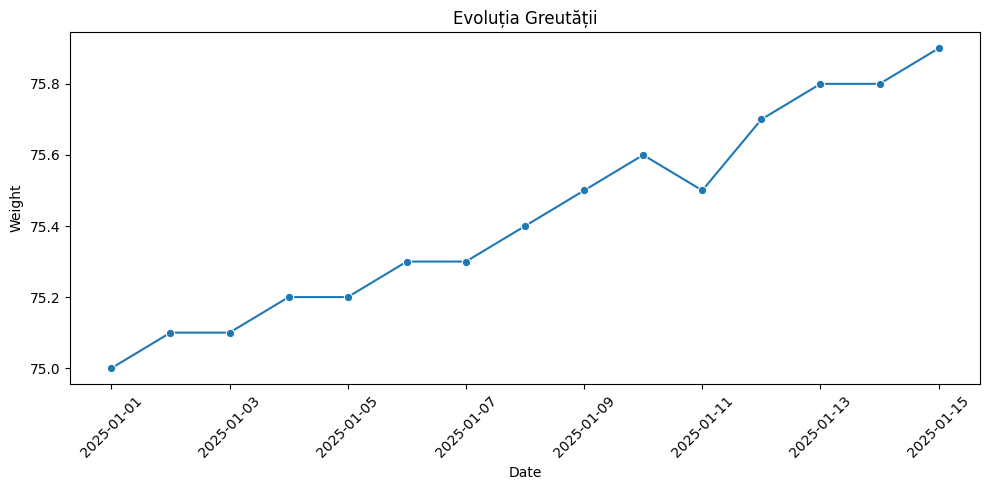

In [10]:
# 2. Analiză Exploratorie (EDA)
print("--- Informații Set de Date ---")
print(df.info())

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date', y='Weight', marker='o')
plt.title('Evoluția Greutății')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# 3. Verificare date curățate
print("--- Informații finale despre setul de date ---")
print(df.info())
print("\nPrimele rânduri:")
print(df.head())
print("\nFormă dataset:", df.shape)

--- Informații finale despre setul de date ---
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              15 non-null     datetime64[us]
 1   Workout_Duration  15 non-null     float64       
 2   Caloric_Intake    15 non-null     float64       
 3   Protein_Intake    15 non-null     float64       
 4   Weight            15 non-null     float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 732.0 bytes
None

Primele rânduri:
        Date  Workout_Duration  Caloric_Intake  Protein_Intake  Weight
0 2025-01-01              60.0          2500.0           150.0    75.0
1 2025-01-02              45.0          2600.0           160.0    75.1
2 2025-01-03               0.0          2400.0           140.0    75.1
3 2025-01-04              75.0          2700.0           170.0    75.2
4 2025-01-05              60.0          25